<a href="https://colab.research.google.com/github/AfsanaAhmedMunia/AHF-Fusion-U-Net/blob/main/AHF_U_Net_(Github).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [2]:
import time
import copy
import numpy as np
import matplotlib.pyplot as plt
from imutils import paths
from sklearn.model_selection import train_test_split
import torch
import torchvision
import torch.nn as nn
import torch.optim as optim
#import torchvision.transforms as transforms
from torchvision import transforms
from torchvision.transforms import CenterCrop
from torch.utils.data import DataLoader, Dataset
import os
import cv2
from torch.nn import Parameter
# torch.manual_seed(42)
# np.random.seed(42)

In [5]:
INPUT_IMAGE_HEIGHT = 240 #352 in original paper
INPUT_IMAGE_WIDTH = 240
BATCH_SIZE = 8
# IMAGE_DATASET_PATH = '/content/gdrive/MyDrive/Phd work/UNet++/Image/'
# MASK_DATASET_PATH = '/content/gdrive/MyDrive/Phd work/UNet++/Mask/'
IMAGE_DATASET_PATH = '/content/gdrive/MyDrive/Phd work/ISIC 2017/ISIC_2017/'
MASK_DATASET_PATH = '/content/gdrive/MyDrive/Phd work/ISIC 2017/ISIC-2017_Training_Part1_GroundTruth/'
# IMAGE_DATASET_PATH = '/content/gdrive/MyDrive/Phd work/ISIC/ISIC_Training_Data/'
# MASK_DATASET_PATH = '/content/gdrive/MyDrive/Phd work/ISIC/ISIC_Training_GroundTruth/'
# IMAGE_DATASET_PATH = '/content/gdrive/MyDrive/Phd work/ISIC18/ISIC2018Training_Input/Matched_ISIC_Training_Data/'
# MASK_DATASET_PATH = '/content/gdrive/MyDrive/Phd work/ISIC18/ISIC2018Training_Input/Matched_ISIC_Training_GroundTruth/'

seed = np.random.randint(2147483647)
np.random.seed(seed)
torch.manual_seed(seed)
TEST_SPLIT = 0.30
# determine the device to be used for training and evaluation
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
# determine if we will be pinning memory during data loading
PIN_MEMORY = True if DEVICE == "cuda" else False

In [6]:
# load the image and mask filepaths in a sorted manner

imagePaths = sorted(list(paths.list_images(IMAGE_DATASET_PATH)))
maskPaths = sorted(list(paths.list_images(MASK_DATASET_PATH)))

trainImages, testImages, trainMasks, testMasks = train_test_split(imagePaths, maskPaths,test_size=TEST_SPLIT, random_state=seed)
len(trainImages), len(testImages), len(trainMasks), len(testMasks)

(1400, 600, 1400, 600)

In [7]:
#create dataset class
from torch.utils.data import Dataset
import cv2
class SegmentationDataset(Dataset):
	def __init__(self, imagePaths, maskPaths, transforms):
		# store the image and mask filepaths, and augmentation
		# transforms
		self.imagePaths = imagePaths
		self.maskPaths = maskPaths
		self.transforms = transforms
	def __len__(self):
		# return the number of total samples contained in the dataset
		return len(self.imagePaths)
	def __getitem__(self, idx):
		# grab the image path from the current index
		imagePath = self.imagePaths[idx]
		image = cv2.imread(imagePath)
		image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
		mask = cv2.imread(self.maskPaths[idx], 0)

		if self.transforms is not None:
			# apply the transformations to both image and its mask
			image = self.transforms(image)
			mask = self.transforms(mask)
		# return a tuple of the image and its mask
		return (image, mask)

In [8]:
# define transformations
from PIL import Image
transforms1 = transforms.Compose([transforms.ToPILImage(),
 	transforms.Resize((INPUT_IMAGE_HEIGHT, INPUT_IMAGE_WIDTH),interpolation= Image.NEAREST),
	transforms.ToTensor()])

# create the train and test datasets
trainDS = SegmentationDataset(imagePaths=trainImages, maskPaths=trainMasks,transforms=transforms1)
testDS = SegmentationDataset(imagePaths=testImages, maskPaths=testMasks,transforms=transforms1)

print(f"[INFO] found {len(trainDS)} examples in the training set...")
print(f"[INFO] found {len(testDS)} examples in the test set...")

# create the training and test data loaders
trainLoader = DataLoader(trainDS, shuffle=True, batch_size= BATCH_SIZE, num_workers=os.cpu_count()) #pin_memory= PIN_MEMORY
testLoader = DataLoader(testDS, shuffle=False, batch_size= BATCH_SIZE, num_workers=os.cpu_count())

[INFO] found 1400 examples in the training set...
[INFO] found 600 examples in the test set...


Shape of the inputs tensor: torch.Size([8, 3, 240, 240])
Shape of the masks tensor: torch.Size([8, 1, 240, 240])


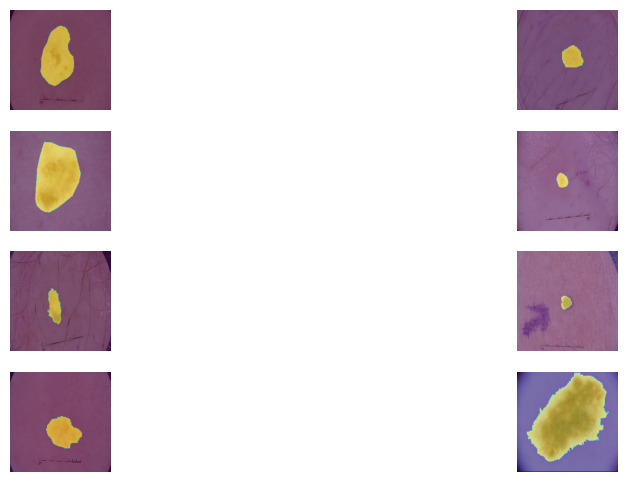

Unique values in the mask tensor: tensor([0., 1.])


In [9]:
import matplotlib.pyplot as plt

# obtain a batch of training data
inputs, masks = next(iter(trainLoader))

print("Shape of the inputs tensor:", inputs.shape)
print("Shape of the masks tensor:", masks.shape)

# plot the images and masks from the batch
fig, axs = plt.subplots(4, 2, figsize=(12, 6))
for i in range(4):
    for j in range(2):
        idx = i*2+j
        # extract the image and mask tensors from the batch
        img_tensor = inputs[idx]
        mask_tensor = masks[idx]
        # convert the tensors to numpy arrays and transpose the dimensions
        img = img_tensor.permute(1, 2, 0).numpy()
        mask = mask_tensor.squeeze().numpy()
        # plot the image and mask side-by-side
        axs[i, j].imshow(img)
        axs[i, j].imshow(mask,alpha = 0.5)
        axs[i, j].axis('off')
plt.show()

unique_values = masks.unique()
print("Unique values in the mask tensor:", unique_values)

In [10]:
class AFF(nn.Module):


    def __init__(self, channels, r=4):
        super(AFF, self).__init__()
        inter_channels = int(channels // r)

        self.local_att = nn.Sequential(
            nn.Conv2d(channels, inter_channels, kernel_size=1, stride=1, padding=0),
            nn.BatchNorm2d(inter_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(inter_channels, channels, kernel_size=1, stride=1, padding=0),
            nn.BatchNorm2d(channels),
        )

        self.global_att = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(channels, inter_channels, kernel_size=1, stride=1, padding=0),
            nn.BatchNorm2d(inter_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(inter_channels, channels, kernel_size=1, stride=1, padding=0),
            nn.BatchNorm2d(channels),
        )

        self.sigmoid = nn.Sigmoid()


    def forward(self, x, outI, feature_Level):
        xa = x + outI + feature_Level # x = I_out4, outI = x5,  feature_Level = x4
        #print("Inside AFF xa: ", xa.size())
        xl = self.local_att(xa)
        #print("Inside AFF xl: ", xl.size())
        xg = self.global_att(xa)
        #print("Inside AFF xg: ", xg.size())
        xlg = xl + xg
        #print("Inside AFF xlg: ", xlg.size())
        wei = self.sigmoid(xlg)

        xo = 2 * x * wei + 2 * outI * (1 - wei)
        #print("Inside AFF xo: ", wei.size())
        return xo


In [ ]:
class Model1(nn.Module):
    def __init__(self, channels):
        super(Model1, self).__init__()

        #for single conv
        self.conv1_single = nn.Conv2d(1, 1, kernel_size=1, padding=0)
        self.conv_single = nn.Conv2d(channels, channels, kernel_size=1, stride=1, padding=0)
        self.spatial_maxpool = nn.AdaptiveMaxPool2d(1)
        self.spatial_avgpool = nn.AdaptiveAvgPool2d(1)
        self.sigmoid = nn.Sigmoid()
        self.relu = nn.ReLU(inplace=True)


    def forward(self, F1, F2, F3):

        FRi = F1 + F2 + F3 # F1 = I_out4, F2 = x5, F3 = x4

        channel_maxpool = torch.max(FRi, dim=1, keepdim=True)[0] # maxpool return two variable(value, index)
        channel_avgpool = torch.mean(FRi, dim=1, keepdim=True)

        xl = self.relu(self.conv_single(FRi)) * FRi
        #print("local features: ", xl.shape)

        # # Global Average Pooling (spatial-wise pooling, channel will be same)
        GAP = self.relu(self.conv_single(self.spatial_avgpool(FRi)))* FRi
        #print("GAP: ", GAP.shape)


        # for single conv
        #GMP = self.sigmoid(self.conv_single(self.spatial_maxpool(FRi)))* FRi
        GMP = self.relu(self.conv_single(self.spatial_maxpool(FRi)))* FRi
        #print("GMP: ", GMP.shape)


        # for single conv
        #MP = self.sigmoid(self.conv1_single(channel_maxpool)) * FRi
        MP = self.relu(self.conv1_single(channel_maxpool)) * FRi
        #print("MP: ", MP.shape)



        # for single conv
        #AP = self.sigmoid(self.conv1_single(channel_avgpool)) * FRi
        AP = self.relu(self.conv1_single(channel_avgpool)) * FRi
        #print("AP:", AP.shape)


        addition = GAP + xl + AP

        addition = self.sigmoid(addition)
        #print("Output: ", addition. shape)

        #xo = 2 * F1 * addition + 2 * F3 * (1 - addition)
        xo = 2 * F1 * addition + 2 * F2 * (1 - addition)
        #print("xo: ", xo. shape)

        return addition
#Sample usage
# fem = Model1(channels=64)
# input_tensor1 = torch.randn(4, 64, 240, 240)
# input_tensor2 = torch.randn(4, 64, 240, 240)
# output_tensor = fem(input_tensor1,input_tensor2)

In [11]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class DoubleConv(nn.Module):
    """(convolution => [BN] => ReLU) * 2"""

    def __init__(self, in_channels, out_channels, mid_channels=None):
        super().__init__()
        if not mid_channels:
            mid_channels = out_channels
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, mid_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(mid_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(mid_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.double_conv(x)


class Down(nn.Module):
    """Downscaling with maxpool then double conv"""

    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.maxpool_conv = nn.Sequential(
            nn.MaxPool2d(2),
            DoubleConv(in_channels, out_channels)
        )

    def forward(self, x):
        return self.maxpool_conv(x)


class Up(nn.Module):
    """Upscaling then double conv"""

    def __init__(self, in_channels, out_channels, AFF_channel, bilinear=False):
    #def __init__(self, in_channels, out_channels, bilinear=True):
        super().__init__()


        #self.model1 = Model1(AFF_channel)
        self.aff= AFF(AFF_channel)
        #self.iaff = iAFF(AFF_channel)


        # if bilinear, use the normal convolutions to reduce the number of channels
        if bilinear:
            self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
            self.conv = DoubleConv(in_channels, out_channels, in_channels) #AFF

        else:
            self.up = nn.ConvTranspose2d(in_channels , in_channels // 2, kernel_size=2, stride=2)
            self.conv = DoubleConv(in_channels//2, out_channels)


    #def forward(self, x1, x2):
    def forward(self, x1, x2, x3):
        #print("inside forward up( initial call) x1 and x2: ", x1.size(),x2.size())
        x1 = self.up(x1) # during first call x1 = x5, x2 = x4 (x1, x2, x3 == x5, I_out_4, x4)
        #print("inside after calling up, x1=x5: ", x1.size())
        #input is CHW
        diffY = x2.size()[2] - x1.size()[2]
        diffX = x2.size()[3] - x1.size()[3]

        x1 = F.pad(x1, [diffX // 2, diffX - diffX // 2,
                        diffY // 2, diffY - diffY // 2])

        #x = self.model1(x2,x1,x3)
        x = self.aff(x2,x1,x3)
        return self.conv(x)


class OutConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(OutConv, self).__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=1)

    def forward(self, x):
       return self.conv(x)


In [12]:
#class CLSCA(nn.Module):
class UAFF(nn.Module):
    def __init__(self, n_channels, n_classes, bilinear=False, dropout_rate=0.0):
        #super(CLSCA, self).__init__()
        super(UAFF, self).__init__()
        self.n_channels = n_channels
        self.n_classes = n_classes
        self.bilinear = bilinear

        self.spatial_avgpool = nn.AdaptiveAvgPool2d(1)
        #channel_maxpool = torch.max(FRi, dim=1, keepdim=True)[0]

        self.conv1 = nn.Sequential(
            nn.Conv2d(64, 64, kernel_size=3, padding=1, stride=1),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_rate),
           )

        self.trans_conv1 = nn.ConvTranspose2d(in_channels=128, out_channels=64, kernel_size=3, stride=2, padding=1, output_padding=1)

        self.conv2 = nn.Sequential(
            nn.Conv2d(128, 128, kernel_size=3, padding=1, stride=1),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_rate),
           )

        self.trans_conv2 = nn.ConvTranspose2d(in_channels=256, out_channels=128, kernel_size=3, stride=2, padding=1, output_padding=1)

        self.conv3 = nn.Sequential(
            nn.Conv2d(256, 256, kernel_size=3, padding=1, stride=1),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_rate),
           )

        self.trans_conv3 = nn.ConvTranspose2d(in_channels=512, out_channels=256, kernel_size=3, stride=2, padding=1, output_padding=1)

        self.conv4 = nn.Sequential(
            nn.Conv2d(512, 512, kernel_size=3, padding=1, stride=1),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_rate),
           )

        self.trans_conv4 = nn.ConvTranspose2d(in_channels=1024, out_channels=512, kernel_size=3, stride=2, padding=1, output_padding=1)


        """ For AFF and iAFF"""
        self.inc = DoubleConv(n_channels, 64)
        self.down1 = Down(64, 128)
        self.down2 = Down(128, 256)
        self.down3 = Down(256, 512)
        #factor = 2 if bilinear else 1
        factor = 2
        self.down4 = Down(512, 1024)
        self.up1 = Up(1024, 512 , 512)
        self.up2 = Up(512, 256, 256)
        self.up3 = Up(256, 128 , 128)
        self.up4 = Up(128, 64, 64)
        self.outc = OutConv(64, n_classes)


    def forward(self, x):
        x1 = self.inc(x)
        s1 = self.spatial_avgpool(x1)
        c1 = torch.mean(x1, dim=1, keepdim=True)
        mul1 = s1 * c1

        x2 = self.down1(x1)
        s2 = self.spatial_avgpool(x2)
        c2 = torch.mean(x2, dim=1, keepdim=True)
        mul2 = s2 * c2

        Trans_conv1 = self.trans_conv1(mul2)
        I_out_1 = self.conv1(mul1 + Trans_conv1)
        I_out_1 = I_out_1 * x1

        x3 = self.down2(x2)
        s3 = self.spatial_avgpool(x3)
        c3 = torch.mean(x3, dim=1, keepdim=True)
        mul3 = s3 * c3

        Trans_conv2 = self.trans_conv2(mul3)
        I_out_2 = self.conv2(mul2 + Trans_conv2)
        I_out_2 =  I_out_2 * x2
        x4 = self.down3(x3)
        s4 = self.spatial_avgpool(x4)
        c4 = torch.mean(x4, dim=1, keepdim=True)
        mul4 = s4 * c4
        Trans_conv3 = self.trans_conv3(mul4)
        I_out_3 = self.conv3(mul3 + Trans_conv3)
        I_out_3 =  I_out_3 * x3

        x5 = self.down4(x4)
        s5 = self.spatial_avgpool(x5)
        c5 = torch.mean(x5, dim=1, keepdim=True)
        mul5 = s5 * c5

        Trans_conv4 = self.trans_conv4(mul5)
        I_out_4 = self.conv4(mul4 + Trans_conv4)
        I_out_4 = I_out_4 * x4


        x = self.up1(x5, I_out_4, x4)
        x = self.up2(x, I_out_3, x3)
        x = self.up3(x, I_out_2, x2)
        x = self.up4(x, I_out_1, x1)
        logits = self.outc(x)

        return logits

In [13]:
from torch.nn import BCEWithLogitsLoss
from tqdm import tqdm
criterion = BCEWithLogitsLoss()
NUM_EPOCHS = 70
trainSteps = len(trainDS) // BATCH_SIZE
testSteps = len(testDS) // BATCH_SIZE

In [14]:
def evaluation_metrices(output, target):
  smooth = 1e-5

  if torch.is_tensor(output):
    output = torch.sigmoid(output).data.cpu().numpy()
  if torch.is_tensor(target):
    target = target.data.cpu().numpy()

    output_ = output > 0.5
    target_ = target > 0.5

    true_positives = (output_ & target_).sum()
    false_positives = (output_ & ~target_).sum()
    false_negatives = (~output_ & target_).sum()
    true_negatives = (~output_ & ~target_).sum()

    sensitivity = (true_positives ) #/ (true_positives + false_negatives )
    specificity = (true_negatives) #/ (true_negatives + false_positives )
    accuracy = (true_positives + true_negatives ) #/ (true_positives + true_negatives + false_positives + false_negatives )


    intersection = true_positives
    union = true_positives + false_positives + false_negatives

    iou = intersection  #/ (union + smooth)
    dice = 2 * intersection  #/ (union + intersection + smooth)

    #iou = (intersection + smooth) / (union + smooth)
    #dice = (2 * intersection + smooth) / (union + intersection + smooth)

    return iou, dice, accuracy, sensitivity, specificity, true_positives, false_positives, false_negatives, true_negatives




moving models to GPU ...
done

[INFO] training the network...


  0%|          | 0/70 [00:00<?, ?it/s]

[INFO] EPOCH: 1/70
Train loss: 0.3740, Val loss: 0.2819, Train_iou: 0.5440, Val_iou: 0.6445
Dice Score: 0.7838, Accuracy: 0.9261, Sensitivity: 0.6970, Specificity: 0.9806


  1%|▏         | 1/70 [06:20<7:17:54, 380.78s/it]

saved best model based on IOU:  0.6444911895548242
[INFO] EPOCH: 2/70
Train loss: 0.2601, Val loss: 0.2189, Train_iou: 0.6459, Val_iou: 0.6807
Dice Score: 0.8100, Accuracy: 0.9339, Sensitivity: 0.7326, Specificity: 0.9819


...

[INFO] EPOCH: 68/70
Train loss: 0.0739, Val loss: 0.1033, Train_iou: 0.8531, Val_iou: 0.8093
Dice Score: 0.8946, Accuracy: 0.9608, Sensitivity: 0.8651, Specificity: 0.9836
EarlyStopping counter: 2 out of 20


 99%|█████████▊| 69/70 [2:34:10<02:10, 130.49s/it]

[INFO] EPOCH: 69/70
Train loss: 0.0641, Val loss: 0.1014, Train_iou: 0.8704, Val_iou: 0.8173
Dice Score: 0.8994, Accuracy: 0.9620, Sensitivity: 0.8847, Specificity: 0.9804
EarlyStopping counter: 3 out of 20


100%|██████████| 70/70 [2:36:19<00:00, 133.99s/it]

[INFO] EPOCH: 70/70
Train loss: 0.0591, Val loss: 0.1181, Train_iou: 0.8803, Val_iou: 0.7991
Dice Score: 0.8883, Accuracy: 0.9587, Sensitivity: 0.8538, Specificity: 0.9837
EarlyStopping counter: 4 out of 20
[INFO] total time taken to train the model: 9379.51s


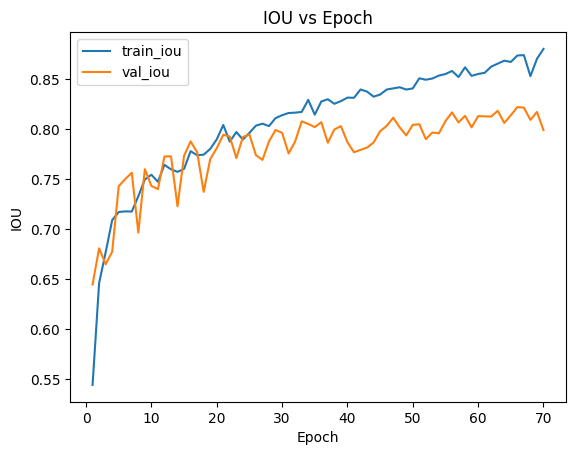

<Figure size 640x480 with 0 Axes>

In [28]:
# my training loop
import pandas as pd
import csv
import os
import time

import matplotlib.pyplot as plt
from torch.optim.lr_scheduler import StepLR
H = {"train_loss": [], "train_iou": [], "val_loss": [],"val_iou": [], "dice_score": [], "accuracy": [], "sensitivity": [], "specificity": []}

def main():


    model = UAFF(3,1,bilinear=False)

    #move to GPU
    print('\nmoving models to GPU ...')
    ##model = torch.nn.DataParallel(model).cuda()
    model.cuda()
    criterion.to(DEVICE)
    print('done\n')


    optimizer = torch.optim.Adam(model.parameters(), lr=2.0e-4, weight_decay=0) # for BUSI 2.0e-4 without scheduler other 1.0e-4 with schedular
    scheduler = StepLR(optimizer, step_size=5, gamma=0.5)
    print("[INFO] training the network...")

    startTime = time.time()

    best_iou = 0
    trigger = 0
    patience = 20

    for e in tqdm(range(NUM_EPOCHS)):
	  # set the model in training mode
          #epoch_start_time = time.time()

          train_loss, train_iou, train_iou_Deno = train_function(trainLoader, model, criterion, optimizer)
          totalValLoss, val_iou, val_dice, val_accuracy,val_sensitivity,val_specificity, val_sen_Deno, val_spc_Deno,val_iou_Deno, val_dice_Deno = val_function(testLoader, model, criterion, optimizer)
          # scheduler.step()


	# calculate the average training and validation loss
          avgTrainLoss = train_loss / trainSteps
          avgTrainIoU = train_iou/ train_iou_Deno
          avgValLoss = totalValLoss / testSteps
          avgValIoU = val_iou / val_iou_Deno
          avgValDice = val_dice/ val_dice_Deno
          avgValAcc = val_accuracy/ (len(testDS)*(240*240))
          avgValSen = val_sensitivity/ val_sen_Deno
          avgValSpe = val_specificity/ val_spc_Deno

          print("[INFO] EPOCH: {}/{}".format(e + 1, NUM_EPOCHS))
          print("Train loss: {:.4f}, Val loss: {:.4f}, Train_iou: {:.4f}, Val_iou: {:.4f}".format(avgTrainLoss, avgValLoss, avgTrainIoU,avgValIoU))
          print("Dice Score: {:.4f}, Accuracy: {:.4f}, Sensitivity: {:.4f}, Specificity: {:.4f}".format(avgValDice,avgValAcc,avgValSen,avgValSpe))

          if avgValIoU > best_iou:

             torch.save(model.state_dict(),'/content/gdrive/MyDrive/Phd work/Saved_model /u-net/UAFF-New-Save/ISIC.pth')
             best_iou=avgValIoU
             print("saved best model based on IOU: ", best_iou )
             trigger = 0
          else:
             trigger += 1
             print(f'EarlyStopping counter: {trigger} out of {patience}')

          if trigger >= patience:
                  print("Early stopping triggered")
                  break

	# update our training history
          if (e%1==0):
              H["train_loss"].append(avgTrainLoss.cpu().detach().numpy())
              H["train_iou"].append(avgTrainIoU) # The cpu() method is used to move the tensor from GPU to CPU (if it is on the GPU)
                                                                      # because numpy arrays can only be created from tensors on CPU.
              H["val_loss"].append(avgValLoss.cpu().detach().numpy())
              H["val_iou"].append(avgValIoU)
              H["dice_score"].append(avgValDice)
              H["accuracy"].append(avgValAcc)
              H["sensitivity"].append(avgValSen)
              H["specificity"].append(avgValSpe)


    endTime = time.time()
    print("[INFO] total time taken to train the model: {:.2f}s".format(endTime - startTime))

    df = pd.DataFrame(H)
    df.to_csv('/content/gdrive/MyDrive/Phd work/Saved_model /u-net/UAFF-New-Save/ISIC.csv', index=False)

    epochs_range = range(1, len(H['train_iou'])+1)

    plt.plot(epochs_range, H['train_iou'], label='train_iou')
    plt.plot(epochs_range, H['val_iou'], label='val_iou')
    plt.title('IOU vs Epoch')
    plt.xlabel('Epoch')
    plt.ylabel('IOU')
    plt.legend()
    plt.show()
    plt.tight_layout()
    time.sleep(4)

    plt.savefig('/content/gdrive/MyDrive/Phd work/Paper_Results/UNet.png')
    torch.cuda.empty_cache()


def train_function(trainLoader, model, criterion, optimizer):
          model.train()
          totalTrainLoss = 0
          train_iou = 0
          train_iou_Deno = 0

	 # loop over the training set
          for (i, (x, y)) in enumerate(trainLoader):
		# send the input to the device
              (x, y) = (x.to(DEVICE), y.to(DEVICE))
              #torch.cuda.empty_cache()
              #gc.collect()
              output = model(x) #output is the raw output from the model
              loss = criterion(output, y)
              optimizer.zero_grad()
              loss.backward()
              optimizer.step()
              totalTrainLoss += loss
              #pred = output.argmax(dim=1)
              iou, dice, accuracy, sensitivity, specificity, true_positives, false_positives, \
              false_negatives, true_negatives = evaluation_metrices(output,y)
              train_iou += iou
              train_iou_Deno += true_positives + false_positives + false_negatives
          return totalTrainLoss, train_iou, train_iou_Deno

def val_function(testLoader, model, criterion, optimizer):
       totalValLoss = 0
       val_iou = 0
       val_dice = 0
       val_accuracy = 0
       val_sensitivity = 0
       val_specificity = 0
       val_sen_Deno = 0
       val_spc_Deno = 0
       val_iou_Deno = 0
       val_dice_Deno = 0

       with torch.no_grad():

              model.eval() # set the model in evaluation mode

              for (x,y) in testLoader:
                  (x, y) = (x.to(DEVICE), y.to(DEVICE))
                  output = model(x)
                  ValLoss = criterion(output, y)
                  totalValLoss += ValLoss
                  iou, dice, accuracy, sensitivity, specificity, true_positives,\
                  false_positives, false_negatives, true_negatives = evaluation_metrices(output,y)
                  val_iou += iou
                  val_dice += dice
                  val_accuracy +=accuracy
                  val_sensitivity += sensitivity
                  val_specificity += specificity
                  val_sen_Deno += true_positives + false_negatives
                  val_spc_Deno += true_negatives + false_positives
                  val_iou_Deno += true_positives + false_positives + false_negatives
                  val_dice_Deno += 2*true_positives + false_positives + false_negatives
              return totalValLoss, val_iou, val_dice, val_accuracy, val_sensitivity, val_specificity, val_sen_Deno, val_spc_Deno, val_iou_Deno, val_dice_Deno


if __name__ == "__main__":

    main()


In [29]:
# Use this if you need to run multiple time
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 362.8/362.8 kB 28.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 233.2/233.2 kB 18.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.6/78.6 kB 6.0 MB/s eta 0:00:00


In [30]:
# import pandas as pd
# import matplotlib.pyplot as plt
# import optuna
# from torch.optim.lr_scheduler import StepLR

# db_url = "sqlite:////content/gdrive/MyDrive/Phd work/SAVE_SQL/test.db"

# def objective(trial):
#     # Define hyperparameters to be optimized
#     lr = trial.suggest_float("lr", 2e-5, 1e-3, log=True)

#     weight_decay = trial.suggest_float("weight_decay", 2e-5, 1e-3, log=True)
#     dropout_rate = trial.suggest_float('dropout_rate', 0.0, 0.5)

#     # Learning rate scheduler parameters
#     step_size = trial.suggest_int('step_size', 1, 10)
#     gamma = trial.suggest_float('gamma', 0.1, 1.0)


#     IoU = main(lr,weight_decay,dropout_rate, step_size, gamma)

#     return IoU



# H = {"train_loss": [], "train_iou": [], "val_loss": [],"val_iou": [], "dice_score": [], "accuracy": [], "sensitivity": [], "specificity": []}


# def main(lr=1e-4, weight_decay=0, dropout_rate = .1, step_size=5, gamma=.1):

#     model = UNetAFF(3,1,bilinear=False,dropout_rate=dropout_rate)

#     print('\nmoving models to GPU ...')
#     model.cuda()
#     criterion.to(DEVICE)
#     print('done\n')

#    # Select optimizer based on trial suggestion

#     optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
#     scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=step_size, gamma=gamma)

#     startTime = time.time()

#     best_iou = 0
#     trigger = 0
#     patience = 20

#     for e in tqdm(range(NUM_EPOCHS)):
# 	  # set the model in training mode
#           train_loss, train_iou, train_iou_Deno = train_function(trainLoader, model, criterion, optimizer)
#           totalValLoss, val_iou, val_dice, val_accuracy,val_sensitivity,val_specificity, val_sen_Deno, val_spc_Deno,val_iou_Deno, val_dice_Deno = val_function(testLoader, model, criterion, optimizer)
#           scheduler.step()

# 	# calculate the average training and validation loss
#           avgTrainLoss = train_loss / trainSteps
#           avgTrainIoU = train_iou/ train_iou_Deno

#           avgValLoss = totalValLoss / testSteps
#           avgValIoU = val_iou / val_iou_Deno
#           avgValDice = val_dice/ val_dice_Deno
#           avgValAcc = val_accuracy/ (len(testDS)*(240*240))
#           avgValSen = val_sensitivity/ val_sen_Deno
#           avgValSpe = val_specificity/ val_spc_Deno

#           print("[INFO] EPOCH: {}/{}".format(e + 1, NUM_EPOCHS))
#           print("Train loss: {:.4f}, Val loss: {:.4f}, Train_iou: {:.4f}, Val_iou: {:.4f}".format(avgTrainLoss, avgValLoss, avgTrainIoU,avgValIoU))
#           print("Dice Score: {:.4f}, Accuracy: {:.4f}, Sensitivity: {:.4f}, Specificity: {:.4f}".format(avgValDice,avgValAcc,avgValSen,avgValSpe))

#           if avgValIoU > best_iou:

#              torch.save(model.state_dict(),'/content/gdrive/MyDrive/Phd work/UNet++/UNetAFF.pth')

#              best_iou=avgValIoU
#              print("saved best model based on IOU: ", best_iou )
#              trigger = 0
#           else:
#              trigger += 1
#              print(f'EarlyStopping counter: {trigger} out of {patience}')

#           if trigger >= patience:
#                   #torch.save(model.state_dict(),'/content/gdrive/MyDrive/Phd work/UNet++/UNetAFF.pth')
#                   print("Early stopping triggered")
#                   break

# 	# update our training history
#           if (e%1==0):
#               H["train_loss"].append(avgTrainLoss.cpu().detach().numpy())
#               H["train_iou"].append(avgTrainIoU) # The cpu() method is used to move the tensor from GPU to CPU (if it is on the GPU)
#                                                                       # because numpy arrays can only be created from tensors on CPU.
#               H["val_loss"].append(avgValLoss.cpu().detach().numpy())
#               H["val_iou"].append(avgValIoU)
#               H["dice_score"].append(avgValDice)
#               H["accuracy"].append(avgValAcc)
#               H["sensitivity"].append(avgValSen)
#               H["specificity"].append(avgValSpe)


#     endTime = time.time()
#     print("[INFO] total time taken to train the model: {:.2f}s".format(endTime - startTime))

#     df = pd.DataFrame(H)

#     df.to_csv('/content/gdrive/MyDrive/Phd work/Paper_Results/UNet_Updated.csv', index=False)

#     epochs_range = range(1, len(H['train_iou'])+1)

#     plt.plot(epochs_range, H['train_iou'], label='train_iou')
#     plt.plot(epochs_range, H['val_iou'], label='val_iou')
#     plt.title('IOU vs Epoch')
#     plt.xlabel('Epoch')
#     plt.ylabel('IOU')
#     plt.legend()
#     plt.show()
#     plt.tight_layout()
#     time.sleep(4)

#     plt.savefig('/content/gdrive/MyDrive/Phd work/Paper_Results/UNet.png')


#     torch.cuda.empty_cache()

#     return avgValIoU


# def train_function(trainLoader, model, criterion, optimizer):
#           model.train()
#           totalTrainLoss = 0
#           train_iou = 0
#           train_iou_Deno = 0

# 	 # loop over the training set
#           for (i, (x, y)) in enumerate(trainLoader):
# 		# send the input to the device
#               (x, y) = (x.to(DEVICE), y.to(DEVICE))
#               #torch.cuda.empty_cache()
#               #gc.collect()
#               output = model(x) #output is the raw output from the model
#               loss = criterion(output, y)
#               optimizer.zero_grad()
#               loss.backward()
#               optimizer.step()
#               totalTrainLoss += loss
#               #pred = output.argmax(dim=1)
#               iou, dice, accuracy, sensitivity, specificity, true_positives, false_positives, \
#               false_negatives, true_negatives = evaluation_metrices(output,y)
#               train_iou += iou
#               train_iou_Deno += true_positives + false_positives + false_negatives
#           return totalTrainLoss, train_iou, train_iou_Deno

# def val_function(testLoader, model, criterion, optimizer):
#        totalValLoss = 0
#        val_iou = 0
#        val_dice = 0
#        val_accuracy = 0
#        val_sensitivity = 0
#        val_specificity = 0
#        val_sen_Deno = 0
#        val_spc_Deno = 0
#        val_iou_Deno = 0
#        val_dice_Deno = 0

#        with torch.no_grad():

#               model.eval() # set the model in evaluation mode

#               for (x,y) in testLoader:
#                   (x, y) = (x.to(DEVICE), y.to(DEVICE))
#                   output = model(x)
#                   ValLoss = criterion(output, y)
#                   totalValLoss += ValLoss
#                   iou, dice, accuracy, sensitivity, specificity, true_positives,\
#                   false_positives, false_negatives, true_negatives = evaluation_metrices(output,y)
#                   val_iou += iou
#                   val_dice += dice
#                   val_accuracy +=accuracy
#                   val_sensitivity += sensitivity
#                   val_specificity += specificity
#                   val_sen_Deno += true_positives + false_negatives
#                   val_spc_Deno += true_negatives + false_positives
#                   val_iou_Deno += true_positives + false_positives + false_negatives
#                   val_dice_Deno += 2*true_positives + false_positives + false_negatives
#               return totalValLoss, val_iou, val_dice, val_accuracy,val_sensitivity, val_specificity, val_sen_Deno, val_spc_Deno, val_iou_Deno, val_dice_Deno


# if __name__ == "__main__":

#     #study = optuna.create_study(direction="maximize")
#     study = optuna.create_study(direction="maximize", study_name="unet-aff-optimization", storage=db_url, load_if_exists=True)

#     study.optimize(objective, n_trials=60)

#     print("Number of finished trials:", len(study.trials))
#     print("Best trial:", study.best_trial.params)


In [15]:
# for evaluation purpose

# IMAGE_DATASET_PATH_E = '/content/gdrive/MyDrive/Phd work/UNet++/Eva_Image/'
# MASK_DATASET_PATH_E = '/content/gdrive/MyDrive/Phd work/UNet++/Eva_mask/'
IMAGE_DATASET_PATH_E = '/content/gdrive/MyDrive/Phd work/ISIC 2017/New_Eva_17/'
MASK_DATASET_PATH_E = '/content/gdrive/MyDrive/Phd work/ISIC 2017/New_Mask_Eva_17/'

imagePaths_E = sorted(list(paths.list_images(IMAGE_DATASET_PATH_E)))
maskPaths_E = sorted(list(paths.list_images(MASK_DATASET_PATH_E)))

trainDS_E = SegmentationDataset(imagePaths=imagePaths_E, maskPaths=maskPaths_E,transforms=transforms1)

print(f"[INFO] found {len(trainDS_E)} examples in the training set...")

trainLoader_E = DataLoader(trainDS_E, shuffle=False, batch_size= 5, num_workers=os.cpu_count())


[INFO] found 5 examples in the training set...


<ipython-input-17-83fb6cc83a50>:13: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('/content/gdrive/MyDrive/Phd work/Saved_model /u-net/UAFF-

output B:  torch.Size([5, 1, 240, 240])
output A:  (5, 240, 240)


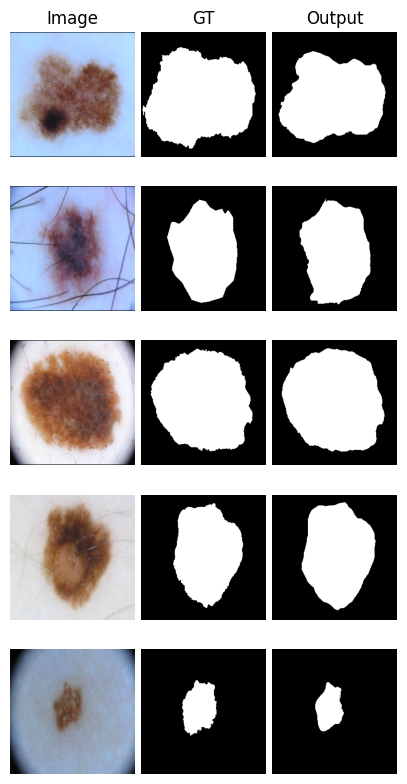

In [17]:
import torch
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import random


#dir_name = '/content/gdrive/MyDrive/Phd work/Paper_Results/Evaluation_image/Final_U_Net_ISIC/'


model =  UAFF(3,1,bilinear=False)
model.load_state_dict(torch.load('/content/gdrive/MyDrive/Phd work/Saved_model /u-net/UAFF-New-Save/ISIC.pth'))

# Load a sample image and mask pair from trainLoader
for image, mask in trainLoader_E:
    break
with torch.no_grad():
    output = model(image)

# Load random sample image and mask pair from trainLoader
# random_samples = random.sample(list(trainLoader_E), 5)
# for i, (image, mask) in enumerate(random_samples):
#     break
# with torch.no_grad():
#     output = model(image)


print("output B: ", output.shape)
output = output.squeeze(1).cpu().numpy()
print("output A: ", output.shape)
#if torch.is_tensor(output):
#output = torch.sigmoid(output).data.cpu().numpy()  have to check with this
output = output > 0.5

# Plot the image, mask, and segmented result
fig, ax = plt.subplots(5, 3, figsize=(5, 10)) #, gridspec_kw={'width_ratios': [1, 1, 1]})
for i in range(5):
    if i==0:
      ax[i][0].set_title('Image')
      ax[i][1].set_title('GT')
      ax[i][2].set_title('Output')

    ax[i][0].imshow(image[i].squeeze().permute(1, 2, 0))
    ax[i][1].imshow(mask[i].squeeze(), cmap='gray')
    ax[i][2].imshow(output[i], cmap='gray')

    fig.subplots_adjust(wspace=0.05,hspace=0.01)

    # saving files for all images
    # flattened_image = image[i].permute(1, 2, 0).reshape(-1, 3).numpy()
    # img_df = pd.DataFrame(flattened_image)
    # mask_df = pd.DataFrame(mask[i].numpy().squeeze(0))
    # out_df = pd.DataFrame(output[i])

    # img_df.to_csv(os.path.join(dir_name,f'img{i}.csv'),index=False)
    # mask_df.to_csv(os.path.join(dir_name, f'mask{i}.csv'),index=False)
    # out_df.to_csv(os.path.join(dir_name,f'output{i}.csv'),index=False)

    for a in ax[i]:
        a.axis('off')

plt.show()